# Global End-to-End Anatomical Landmark Detection for Long-Leg Radiographs

This notebook trains a unified one-stage Conformer model to regress 12 surgical
keypoints directly on full-size long-leg radiographs, bypassing any intermediate
YOLO sub-cropping step. It covers data loading, augmentation, model training with
MSE + PCK evaluation, 5-fold cross-validation (including per-fold correction angle
MAE), and a full surgical-correction-angle analysis on the held-out test set.

## Imports & Configuration

Load all necessary deep-learning packages, configure paths to the CKD Conformer
repository, and fix global hyperparameter constants.

In [1]:
import os
import json
import random
import math
import sys
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn

sys.path.append(os.path.abspath("CKD"))
from models import (
    Conformer_tiny_patch16_keypoint_half_heatmap,
    Conformer_small_patch16_keypoint_half_heatmap,
    Conformer_small_patch32_keypoint_half_heatmap,
    Conformer_base_patch16_keypoint_half_heatmap,
)
from utils import extract_coordinates

DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED           = 42
TARGET_SIZE    = 768
HEATMAP_SCALE  = 0.5
SIGMA          = 6.0
KP_EPOCHS      = 2_000
BATCH_SIZE     = 4
LEARNING_RATE  = 1e-4 * (HEATMAP_SCALE / 0.25)

MODEL_VARIANT   = "small_p16"
CHECKPOINT_PATH = "best_model_global.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh",
    "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh",
    "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh",
]

LANDMARK_COLORS = {
    "femur_head_lh":      "darkgreen",  "knee_inner_lh":    "darkblue",
    "ost_point_lh":       "darkred",    "knee_outer_lh":    "darkviolet",
    "ankle_inner_lh":     "darkorange", "ankle_outer_lh":   "teal",
    "fujisawa_lh":        "gold",       "ankle_c_lh":       "navy",
    "target_at_ankle_lh": "magenta",
    "femur_head_rh":      "lightgreen", "knee_inner_rh":    "lightblue",
    "ost_point_rh":       "lightcoral", "knee_outer_rh":    "plum",
    "ankle_inner_rh":     "sandybrown", "ankle_outer_rh":   "paleturquoise",
    "fujisawa_rh":        "khaki",      "ankle_c_rh":       "slategray",
    "target_at_ankle_rh": "violet",
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

Hardware device registered: cuda


## GPU Availability Check

Validate hardware acceleration before committing to a long training run.

In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")
if gpu_available:
    print(f"GPU device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
GPU available: True
GPU device name: NVIDIA H100 80GB HBM3


## Dataset Architecture

The dataset pipeline has three stages:

1. **Preprocessing** – letterbox-resize each radiograph to `TARGET_SIZE × TARGET_SIZE`,
   recording padding offsets for later coordinate remapping.
2. **Augmentation** – applied only during training: brightness/contrast, Gaussian noise,
   gamma, CLAHE, sharpening, rotation ±10°, vertical shift, scale jitter ±10%.
3. **`GlobalRadiographKeypointDataset`** – maps COCO annotations to a 12-channel
   heatmap target and paired ground-truth coordinates.
   The optional `indices` argument accepts an explicit list of sample positions,
   used by the k-fold cross-validation loop.

In [3]:
def preprocess_global_image(img, target_size=512):
    """Letterbox-resize *img* to a square canvas of *target_size* pixels."""
    orig_w, orig_h = img.size
    scale   = min(target_size / orig_w, target_size / orig_h)
    new_w   = int(orig_w * scale)
    new_h   = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)


def apply_augmentation(pil_img, final_kps):
    """Stochastic photometric and geometric augmentations.
    Returns (augmented_img, updated_kps)."""
    import torchvision.transforms.functional as TF
    import cv2

    img = pil_img
    kps = [list(kp) for kp in final_kps]
    W, H = img.size

    if random.random() < 0.6:
        img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.6:
        img = TF.adjust_contrast(img, 1.0 + random.uniform(-0.25, 0.25))

    if random.random() < 0.4:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(3, 12), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    if random.random() < 0.5:
        gamma = random.uniform(0.7, 1.4)
        arr   = np.array(img, dtype=np.float32) / 255.0
        img   = Image.fromarray((np.power(arr, gamma) * 255).astype(np.uint8))

    if random.random() < 0.4:
        arr       = np.array(img)
        clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(arr[:, :, 0])
        img       = Image.fromarray(np.stack([processed] * 3, axis=2))

    if random.random() < 0.3:
        img = TF.adjust_sharpness(img, random.uniform(0.5, 2.0))

    if random.random() < 0.5:
        angle    = random.uniform(-10, 10)
        img      = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        cx, cy   = W / 2.0, H / 2.0
        rad      = math.radians(-angle)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        for kp in kps:
            if kp[0] < 0: continue
            dx, dy = kp[0] - cx, kp[1] - cy
            kp[0]  = cos_a * dx - sin_a * dy + cx
            kp[1]  = sin_a * dx + cos_a * dy + cy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        shift_y = random.randint(-15, 15)
        img = TF.affine(img, angle=0, translate=(0, shift_y), scale=1.0, shear=0)
        for kp in kps:
            if kp[0] < 0: continue
            kp[1] += shift_y
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        sf    = random.uniform(0.90, 1.10)
        new_w = int(W * sf); new_h = int(H * sf)
        img   = TF.resize(img, [new_h, new_w])
        if sf < 1.0:
            pl, pt = (W - new_w) // 2, (H - new_h) // 2
            padded = Image.new("RGB", (W, H), (0, 0, 0))
            padded.paste(img, (pl, pt))
            img = padded; ox, oy = pl, pt
        else:
            cl, ct = (new_w - W) // 2, (new_h - H) // 2
            img = TF.crop(img, ct, cl, H, W); ox, oy = -cl, -ct
        for kp in kps:
            if kp[0] < 0: continue
            kp[0] = kp[0] * sf + ox; kp[1] = kp[1] * sf + oy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    return img, kps

In [4]:
class GlobalRadiographKeypointDataset(Dataset):
    """COCO-style dataset for global 12-keypoint detection on long-leg radiographs.

    Parameters
    ----------
    indices : list[int] or None
        Explicit sample positions into the shuffled pool.  When given the
        split_ratios are ignored — used for k-fold cross validation.
    """

    def __init__(
        self,
        coco_json_path,
        split="train",
        split_ratios=(0.8, 0.1, 0.1),
        target_size=512,
        heatmap_scale=0.25,
        sigma=2.0,
        seed=42,
        indices=None,
    ):
        super().__init__()
        self.target_size   = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma         = sigma
        self.num_keypoints = 12
        self.split         = split

        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)

        images_info = {img["id"]: img for img in coco_data.get("images", [])}
        anns_by_img: dict = {}
        for ann in coco_data.get("annotations", []):
            img_id = ann.get("image_id")
            anns_by_img.setdefault(img_id, []).append(ann)

        valid_samples = []
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info: continue
            img_info = images_info[img_id]
            img_w    = img_info.get("width", 2860)
            kps_flat = [-1.0, -1.0, 0] * 12
            has_kp   = False

            for ann in anns:
                kps = ann.get("keypoints", [])
                if not kps: continue
                ann_cx = ann.get("bbox", [0,0,0,0])[0] + ann.get("bbox", [0,0,0,0])[2] / 2.0
                base   = 0 if ann_cx < img_w / 2.0 else 6
                cat_id = ann.get("category_id")
                if cat_id == 1 and len(kps) >= 2:
                    kps_flat[base*3:(base+1)*3] = [kps[0], kps[1], 2 if kps[0]>0 else 0]
                    if kps[0] > 0: has_kp = True
                elif cat_id == 2 and len(kps) >= 9:
                    for k in range(3):
                        idx = base + 1 + k
                        kps_flat[idx*3:(idx+1)*3] = [kps[k*3], kps[k*3+1], kps[k*3+2]]
                        if kps[k*3+2] > 0: has_kp = True
                elif cat_id == 3 and len(kps) >= 6:
                    for k in range(2):
                        idx = base + 4 + k
                        kps_flat[idx*3:(idx+1)*3] = [kps[k*3], kps[k*3+1], kps[k*3+2]]
                        if kps[k*3+2] > 0: has_kp = True

            if has_kp:
                filename = img_info.get("file_name")
                img_dir  = os.path.dirname(coco_json_path) or "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    if os.path.exists(os.path.join("/tf/data/hto/xrays", os.path.basename(filename))):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path":  os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat,
                })

        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)

        if indices is not None:
            self.samples = [valid_samples[i] for i in indices]
        else:
            n         = len(valid_samples)
            train_end = int(n * split_ratios[0])
            val_end   = train_end + int(n * split_ratios[1])
            self.samples = {
                "train": valid_samples[:train_end],
                "val":   valid_samples[train_end:val_end],
                "test":  valid_samples[val_end:],
            }.get(split, valid_samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))

        processed_img, scale, padding = preprocess_global_image(img, self.target_size)

        final_kps, kp_visibility = [], []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_kps.append([kp_x * scale + padding[0], kp_y * scale + padding[1]])
                kp_visibility.append(1.0)
            else:
                final_kps.append([-1.0, -1.0])
                kp_visibility.append(0.0)

        if self.split == "train":
            processed_img, final_kps = apply_augmentation(processed_img, final_kps)
            kp_visibility = [1.0 if final_kps[i][0] >= 0 else 0.0 for i in range(self.num_keypoints)]

        img_tensor = torch.from_numpy(np.array(processed_img)).permute(2, 0, 1).float() / 255.0
        img_tensor = (img_tensor - torch.tensor([0.485,0.456,0.406]).view(3,1,1))                    / torch.tensor([0.229,0.224,0.225]).view(3,1,1)

        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid  = np.arange(0, hm_size, 1, np.float32)
        y_grid  = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
        for i in range(self.num_keypoints):
            if sample["keypoints"][i * 3 + 2] > 0 and final_kps[i][0] >= 0:
                hx, hy     = final_kps[i][0] * self.heatmap_scale, final_kps[i][1] * self.heatmap_scale
                heatmap[i] = np.exp(-((x_grid-hx)**2 + (y_grid-hy)**2) / (2 * self.sigma**2))

        return {
            "image":     img_tensor,
            "heatmap":   torch.from_numpy(heatmap),
            "keypoint":  torch.tensor(final_kps, dtype=torch.float32),
            "visibility":torch.tensor(kp_visibility, dtype=torch.float32),
            "img_path":  sample["img_path"],
            "orig_size": torch.tensor(sample["orig_size"]),
        }

In [5]:
if os.path.exists(COCO_JSON_PATH):
    _kw = dict(num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

    train_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="train",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    val_ds   = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    test_ds  = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="test",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)

    if len(train_ds) > 0: train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **_kw)
    if len(val_ds)   > 0: val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **_kw)
    if len(test_ds)  > 0: test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **_kw)

    print(f"Datasets ready:  {len(train_ds)} train  |  {len(val_ds)} val  |  {len(test_ds)} test")
else:
    print("Annotation file not found — data loading skipped.")

Datasets ready:  43 train  |  5 val  |  6 test


## Model Initialization & Metric Functions

Defines the heatmap loss, keypoint MSE, and PCK metrics, then instantiates the
Conformer model with its optimizer and learning-rate scheduler.

In [6]:
def masked_heatmap_loss(pred_hms, target_hms, visibility):
    """Per-channel MSE loss masked to visible keypoints."""
    mask        = visibility.unsqueeze(-1).unsqueeze(-1)
    masked_diff = (pred_hms - target_hms) ** 2 * mask
    H, W        = pred_hms.shape[-2], pred_hms.shape[-1]
    return masked_diff.sum() / (mask.sum().clamp(min=1) * H * W)


def calculate_mse(preds, gts):
    """Mean Squared Error (px\u00b2) over all valid keypoints."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    return torch.mean(torch.sum((preds - gts) ** 2, dim=-1)[valid_mask]).item()


def calculate_pck(preds, gts, threshold=0.05, normalize_by=512):
    """Percentage of Correct Keypoints at *threshold* \u00d7 *normalize_by* px."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    correct = torch.norm(preds - gts, dim=-1) < (threshold * normalize_by)
    return torch.mean(correct[valid_mask].float()).item()


PCK_THRESHOLDS = [0.005, 0.01, 0.02, 0.05]

In [7]:
_model_map = {
    "tiny":      Conformer_tiny_patch16_keypoint_half_heatmap,
    "small_p16": Conformer_small_patch16_keypoint_half_heatmap,
    "small_p32": Conformer_small_patch32_keypoint_half_heatmap,
    "base":      Conformer_base_patch16_keypoint_half_heatmap,
}

model_global     = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
optimizer_global = optim.AdamW(model_global.parameters(), lr=LEARNING_RATE)
scheduler_global = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_global, T_max=KP_EPOCHS, eta_min=1e-6
)
print(f"Model variant '{MODEL_VARIANT}' initialised on {device}.")

Model variant 'small_p16' initialised on cuda.


## Surgical Geometry Utilities

These functions are shared between the k-fold correction-angle evaluation and the
final test-set analysis.

* **`map_global_to_orig`** – inverts the letterbox transform to recover original
  image coordinates from the padded-canvas predictions.
* **`calculate_intersection`** – finds where a line crosses a horizontal target.
* **`evaluate_side_geometry`** – applies the Miniaci method to compute the
  Fujisawa point, the target ankle intersection, and the correction angle Alpha
  for one leg hemisphere.
* **`evaluate_fold_angles`** – runs full inference on a data loader and returns
  the mean absolute correction-angle error; called once per fold after training.

In [8]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    """Invert the letterbox transform back to original image coordinates."""
    orig_w, orig_h = orig_size
    scale    = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top  = (target_size - int(orig_h * scale)) // 2
    return np.array([(kp_final[0] - pad_left) / scale,
                     (kp_final[1] - pad_top)  / scale])


def calculate_intersection(p1, p2, target_y):
    """X-coordinate where line (p1 → p2) crosses y = *target_y*."""
    if p2[0] == p1[0]: return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0:
        return p1[0] if abs(target_y - p1[1]) < 1e-9 else float("nan")
    return (target_y - p1[1]) / m + p1[0]


def evaluate_side_geometry(points):
    """Compute the Miniaci correction angle Alpha for one leg hemisphere.

    Parameters
    ----------
    points : dict with keys femur_head, knee_inner, ost_point,
             knee_outer, ankle_inner, ankle_outer (2-element arrays)

    Returns
    -------
    alpha, fujisawa, ankle_c, target_at_ankle
    """
    ankle_c  = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])

    tx              = calculate_intersection(points["femur_head"], fujisawa, ankle_c[1])
    target_at_ankle = np.array([tx, ankle_c[1]])

    v_orig   = ankle_c         - points["ost_point"]
    v_target = target_at_ankle - points["ost_point"]
    raw      = abs(math.atan2(v_orig[1], v_orig[0]) - math.atan2(v_target[1], v_target[0]))
    alpha    = min(raw, 2 * math.pi - raw) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle


_SIDE_KEYS = ["femur_head", "knee_inner", "ost_point",
              "knee_outer", "ankle_inner", "ankle_outer"]


def evaluate_fold_angles(model, v_loader, dev):
    """Run inference on *v_loader* and return a dict of correction-angle
    error statistics across all valid hemisphere cases:

        mae  – mean absolute error (degrees)
        std  – standard deviation of absolute errors (degrees)
        max  – maximum absolute error (degrees)
        n    – number of valid hemisphere cases evaluated

    Returns None if no valid hemisphere pairs are found.
    """
    model.eval()
    abs_errors = []

    with torch.no_grad():
        for batch in v_loader:
            imgs         = batch["image"].to(dev)
            pred_hms     = torch.sigmoid(model(imgs))
            coords_batch = extract_coordinates(
                pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE
            ).numpy()
            gts_batch  = batch["keypoint"].numpy()
            orig_sizes = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c     = coords_batch[b]
                gt_c       = gts_batch[b]

                for base in [0, 6]:   # left hemisphere, right hemisphere
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if (all(k in pts_gt   for k in _SIDE_KEYS) and
                            all(k in pts_pred for k in _SIDE_KEYS)):
                        gt_alpha,   *_ = evaluate_side_geometry(pts_gt)
                        pred_alpha, *_ = evaluate_side_geometry(pts_pred)
                        abs_errors.append(abs(pred_alpha - gt_alpha))

    if not abs_errors:
        return None
    arr = np.array(abs_errors)
    return {"mae": float(arr.mean()),
            "std": float(arr.std()),
            "max": float(arr.max()),
            "n":   len(arr)}

## Training Loop

`train_global_routine` runs the full train / validation cycle.  Each epoch it
trains on the training loader, then evaluates MSE and PCK at all four thresholds
on the validation loader, saving the checkpoint whenever a new best MSE is reached.

In [9]:
def train_global_routine(
    model, t_loader, v_loader, opt, scheduler, epochs, dev,
    checkpoint_path=CHECKPOINT_PATH,
):
    """Train and validate for *epochs* epochs.

    Returns
    -------
    t_losses, v_losses : list[float]  — per-epoch heatmap MSE loss
    v_mses             : list[float]  — per-epoch keypoint MSE (px\u00b2)
    v_pcks_all         : list[dict]   — per-epoch {threshold: PCK} dicts
    """
    t_losses, v_losses, v_mses, v_pcks_all = [], [], [], []
    best_mse = float("inf")

    for e in range(epochs):
        model.train()
        e_loss = 0.0
        for batch in t_loader:
            imgs, target_hms, vis = (batch["image"].to(dev),
                                     batch["heatmap"].to(dev),
                                     batch["visibility"].to(dev))
            opt.zero_grad()
            loss = masked_heatmap_loss(torch.sigmoid(model(imgs)), target_hms, vis)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            e_loss += loss.item()

        scheduler.step()
        t_l = e_loss / len(t_loader)
        t_losses.append(t_l)

        model.eval()
        v_loss = 0.0
        epoch_preds, epoch_gts = [], []
        with torch.no_grad():
            for batch in v_loader:
                imgs, target_hms, vis, gts = (batch["image"].to(dev),
                                               batch["heatmap"].to(dev),
                                               batch["visibility"].to(dev),
                                               batch["keypoint"])
                pred_hms = torch.sigmoid(model(imgs))
                v_loss  += masked_heatmap_loss(pred_hms, target_hms, vis).item()
                epoch_preds.append(extract_coordinates(pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE))
                epoch_gts.append(gts)

        v_l = v_loss / len(v_loader)
        v_losses.append(v_l)

        preds_cat = torch.cat(epoch_preds)
        gts_cat   = torch.cat(epoch_gts)
        mse_val   = calculate_mse(preds_cat, gts_cat)
        if mse_val < best_mse:
            best_mse = mse_val
            torch.save(model.state_dict(), checkpoint_path)

        pck_vals = {t: calculate_pck(preds_cat, gts_cat, threshold=t, normalize_by=TARGET_SIZE)
                    for t in PCK_THRESHOLDS}
        v_mses.append(mse_val)
        v_pcks_all.append(pck_vals)

        print(f"Epoch {e+1:04d}/{epochs} | "
              f"Train: {t_l:.6f} | Val: {v_l:.6f} | "
              f"MSE: {mse_val:.2f} px\u00b2 | "
              f"PCK@0.005: {pck_vals[0.005]*100:.1f}% | "
              f"PCK@0.01: {pck_vals[0.01]*100:.1f}% | "
              f"PCK@0.02: {pck_vals[0.02]*100:.1f}% | "
              f"PCK@0.05: {pck_vals[0.05]*100:.1f}%")

    return t_losses, v_losses, v_mses, v_pcks_all

## 5-Fold Cross Validation

5-fold CV estimates generalisation performance across the **entire** dataset.
Each fold trains a fresh model on 4/5 of the data and evaluates on the remaining
1/5, reporting three metrics:

* **Keypoint MSE** (px²) — average squared localisation error
* **PCK** at all four normalised thresholds
* **Correction angle MAE** (°) — mean absolute error in the Miniaci Alpha angle,
  computed by loading the fold's best checkpoint and running the full
  `evaluate_fold_angles` pipeline on the validation subset

In [10]:
from sklearn.model_selection import KFold


def run_kfold_cv(coco_json_path, n_splits=5, epochs=KP_EPOCHS, batch_size=BATCH_SIZE):
    """Run n-fold cross validation.  Returns a list of per-fold result dicts."""
    full_ds = GlobalRadiographKeypointDataset(
        coco_json_path, split="all",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED,
    )
    n_samples = len(full_ds)
    print(f"Total samples for {n_splits}-fold CV: {n_samples}")

    kf           = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(n_samples))):
        print(f"\n{'='*65}")
        print(f"  FOLD {fold+1}/{n_splits}  |  {len(train_idx)} train  /  {len(val_idx)} val")
        print(f"{'='*65}")

        _kw = dict(num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
        train_ds_f = GlobalRadiographKeypointDataset(
            coco_json_path, split="train", target_size=TARGET_SIZE,
            heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=train_idx)
        val_ds_f = GlobalRadiographKeypointDataset(
            coco_json_path, split="val", target_size=TARGET_SIZE,
            heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=val_idx)
        t_loader_f = DataLoader(train_ds_f, batch_size=batch_size, shuffle=True,  **_kw)
        v_loader_f = DataLoader(val_ds_f,   batch_size=batch_size, shuffle=False, **_kw)

        model_f     = _model_map[MODEL_VARIANT](num_keypoints=12).to(device)
        optimizer_f = optim.AdamW(model_f.parameters(), lr=LEARNING_RATE)
        scheduler_f = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_f, T_max=epochs, eta_min=1e-6)

        ckpt_f = f"best_model_fold{fold+1}.pt"
        t_losses_f, v_losses_f, v_mses_f, v_pcks_all_f = train_global_routine(
            model_f, t_loader_f, v_loader_f,
            optimizer_f, scheduler_f, epochs, device, ckpt_f,
        )

        best_mse_f  = min(v_mses_f)
        best_pcks_f = {t: max(p[t] for p in v_pcks_all_f) for t in PCK_THRESHOLDS}

        # ── Correction-angle statistics ───────────────────────────────────────
        # Load the best-MSE checkpoint, then run the full Miniaci geometry
        # pipeline on the validation subset to get MAE, std, and max error.
        model_f.load_state_dict(torch.load(ckpt_f, weights_only=True))
        angle_stats = evaluate_fold_angles(model_f, v_loader_f, device)

        fold_results.append({
            "fold":        fold + 1,
            "best_mse":    best_mse_f,
            "best_pcks":   best_pcks_f,
            "angle_stats": angle_stats,
            "t_losses":    t_losses_f,
            "v_losses":    v_losses_f,
            "v_mses":      v_mses_f,
            "v_pcks_all":  v_pcks_all_f,
        })

        if angle_stats:
            print(f"\nFold {fold+1} best  |  "
                  f"MSE: {best_mse_f:.2f} px\u00b2  |  "
                  f"PCK@0.01: {best_pcks_f[0.01]*100:.1f}%  |  "
                  f"Angle MAE: {angle_stats['mae']:.3f}\u00b0  "
                  f"Std: {angle_stats['std']:.3f}\u00b0  "
                  f"Max: {angle_stats['max']:.3f}\u00b0  "
                  f"(n={angle_stats['n']})")
        else:
            print(f"\nFold {fold+1} best  |  "
                  f"MSE: {best_mse_f:.2f} px\u00b2  |  "
                  f"PCK@0.01: {best_pcks_f[0.01]*100:.1f}%  |  Angle: N/A")

    return fold_results


def plot_kfold_summary(fold_results):
    """Bar-chart summary with a printed mean \u00b1 std table.

    Three panels:
      1. Keypoint MSE per fold
      2. PCK at all thresholds per fold (grouped bars)
      3. Correction angle MAE per fold with std error bars; max shown as
         individual markers above each bar
    """
    n_folds    = len(fold_results)
    folds      = [r["fold"]     for r in fold_results]
    mses       = [r["best_mse"] for r in fold_results]
    pcks       = {t: [r["best_pcks"][t]*100 for r in fold_results] for t in PCK_THRESHOLDS}
    ang        = [r.get("angle_stats") for r in fold_results]
    has_angles = any(a is not None for a in ang)

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    # 1. Keypoint MSE
    axes[0].bar(folds, mses, color="steelblue", edgecolor="black", alpha=0.8)
    axes[0].axhline(np.mean(mses), color="red", linestyle="--",
                    label=f"Mean: {np.mean(mses):.2f} px\u00b2")
    axes[0].set_title("Keypoint MSE per Fold")
    axes[0].set_xlabel("Fold"); axes[0].set_ylabel("Best Val MSE (px\u00b2)")
    axes[0].set_xticks(folds); axes[0].legend(); axes[0].grid(True, axis="y", alpha=0.4)

    # 2. PCK (grouped bars)
    x = np.arange(n_folds); w = 0.18
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    for i, t in enumerate(PCK_THRESHOLDS):
        axes[1].bar(x + i*w, pcks[t], width=w, label=f"PCK@{t}",
                    color=colors[i], edgecolor="black", alpha=0.8)
    axes[1].set_title("PCK @ All Thresholds per Fold")
    axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Best Val PCK (%)")
    axes[1].set_xticks(x + w*1.5)
    axes[1].set_xticklabels([f"Fold {i+1}" for i in range(n_folds)])
    axes[1].legend(); axes[1].grid(True, axis="y", alpha=0.4)

    # 3. Correction-angle MAE + std error bars + max markers
    if has_angles:
        maes = [a["mae"] if a else 0.0 for a in ang]
        stds = [a["std"] if a else 0.0 for a in ang]
        maxs = [a["max"] if a else 0.0 for a in ang]
        mean_mae = np.mean([a["mae"] for a in ang if a])

        axes[2].bar(folds, maes, color="mediumseagreen", edgecolor="black", alpha=0.8,
                    yerr=stds, capsize=5, error_kw=dict(ecolor="black", elinewidth=1.2),
                    label="MAE \u00b1 std")
        axes[2].scatter(folds, maxs, marker="^", color="firebrick", zorder=5,
                        s=60, label="Max error")
        axes[2].axhline(mean_mae, color="red", linestyle="--",
                        label=f"Mean MAE: {mean_mae:.3f}\u00b0")
        axes[2].set_title("Correction Angle Error per Fold")
        axes[2].set_xlabel("Fold"); axes[2].set_ylabel("Angle Error (\u00b0)")
        axes[2].set_xticks(folds); axes[2].legend(); axes[2].grid(True, axis="y", alpha=0.4)
    else:
        axes[2].set_visible(False)

    plt.suptitle("5-Fold Cross Validation Summary", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── Summary table ────────────────────────────────────────────────────────
    print("\n" + "="*65)
    print("5-FOLD CROSS VALIDATION SUMMARY")
    print("="*65)
    print(f"Keypoint MSE (px\u00b2):  {np.mean(mses):.2f}  \u00b1  {np.std(mses):.2f}")
    for t in PCK_THRESHOLDS:
        v = pcks[t]
        print(f"PCK@{t}:            {np.mean(v):.1f}%  \u00b1  {np.std(v):.1f}%")
    if has_angles:
        valid = [a for a in ang if a]
        maes_v = [a["mae"] for a in valid]
        stds_v = [a["std"] for a in valid]
        maxs_v = [a["max"] for a in valid]
        print(f"Angle MAE (\u00b0):      {np.mean(maes_v):.3f}  \u00b1  {np.std(maes_v):.3f}")
        print(f"Angle Std (\u00b0):      {np.mean(stds_v):.3f}  \u00b1  {np.std(stds_v):.3f}")
        print(f"Angle Max (\u00b0):      {np.mean(maxs_v):.3f}  \u00b1  {np.std(maxs_v):.3f}")
    print("="*65)

Total samples for 5-fold CV: 54

  FOLD 1/5  |  43 train  /  11 val
Epoch 0001/2000 | Train: 0.248766 | Val: 0.259685 | MSE: 99109.88 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0002/2000 | Train: 0.231602 | Val: 0.240461 | MSE: 122037.30 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.8%
Epoch 0003/2000 | Train: 0.222370 | Val: 0.224289 | MSE: 187175.05 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0004/2000 | Train: 0.215152 | Val: 0.217201 | MSE: 198074.33 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.8%
Epoch 0005/2000 | Train: 0.208820 | Val: 0.205004 | MSE: 195546.05 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0006/2000 | Train: 0.202387 | Val: 0.197750 | MSE: 249875.56 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0007/2000 | Train: 0.195332 | Val: 0.190657 | MSE: 279384.59 px² | PCK@0.005: 0.0% | PC

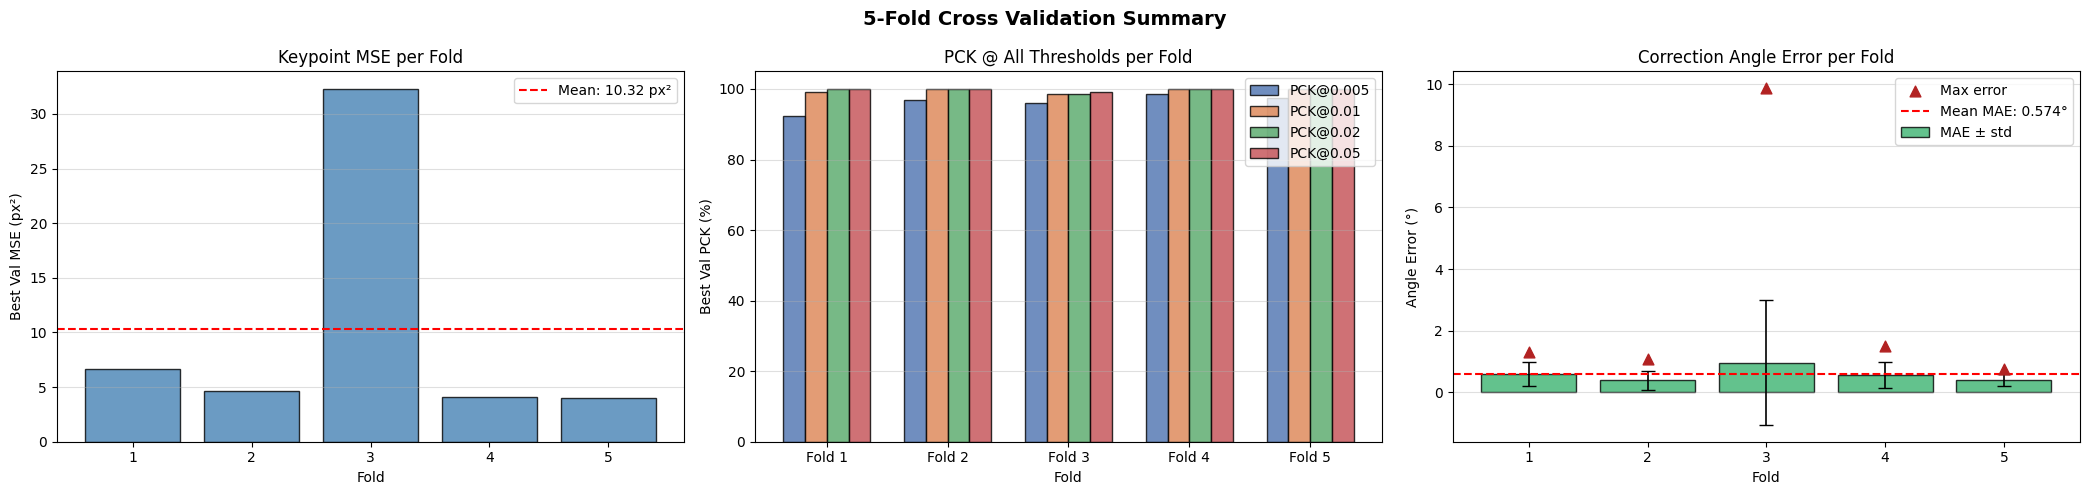


5-FOLD CROSS VALIDATION SUMMARY
Keypoint MSE (px²):  10.32  ±  11.02
PCK@0.005:            96.3%  ±  2.1%
PCK@0.01:            99.5%  ±  0.6%
PCK@0.02:            99.7%  ±  0.6%
PCK@0.05:            99.8%  ±  0.3%
Angle MAE (°):      0.574  ±  0.210
Angle Std (°):      0.667  ±  0.683
Angle Max (°):      2.900  ±  3.498


In [11]:
if os.path.exists(COCO_JSON_PATH):
    fold_results = run_kfold_cv(COCO_JSON_PATH, n_splits=5, epochs=KP_EPOCHS)
    plot_kfold_summary(fold_results)
else:
    print("Annotation file not found — 5-fold CV skipped.")

## Final Training Run

With cross validation complete, train the model on the fixed 80 / 10 / 10 split
and save the best checkpoint (lowest validation MSE).

In [12]:
if 'train_loader' in locals():
    model_global.train()
    _ = torch.sigmoid(model_global(next(iter(train_loader))["image"].to(device)))

    train_losses, val_losses, val_mses, val_pcks_all = train_global_routine(
        model_global, train_loader, val_loader,
        optimizer_global, scheduler_global, KP_EPOCHS, device,
    )
    model_global.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
    print(f"Best checkpoint loaded from '{CHECKPOINT_PATH}'.")
else:
    print("Data loaders not initialised — training skipped.")

Epoch 0001/2000 | Train: 0.250496 | Val: 0.260375 | MSE: 126788.90 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0002/2000 | Train: 0.226471 | Val: 0.239024 | MSE: 160322.08 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 1.7%
Epoch 0003/2000 | Train: 0.214343 | Val: 0.222235 | MSE: 261680.50 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0004/2000 | Train: 0.207194 | Val: 0.207106 | MSE: 269354.66 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 1.7%
Epoch 0005/2000 | Train: 0.200422 | Val: 0.199315 | MSE: 213018.72 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 1.7%
Epoch 0006/2000 | Train: 0.194386 | Val: 0.196102 | MSE: 125912.80 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 0.0%
Epoch 0007/2000 | Train: 0.188656 | Val: 0.186910 | MSE: 203950.64 px² | PCK@0.005: 0.0% | PCK@0.01: 0.0% | PCK@0.02: 0.0% | PCK@0.05: 1.7%
Epoch 0008/2000 | Tr

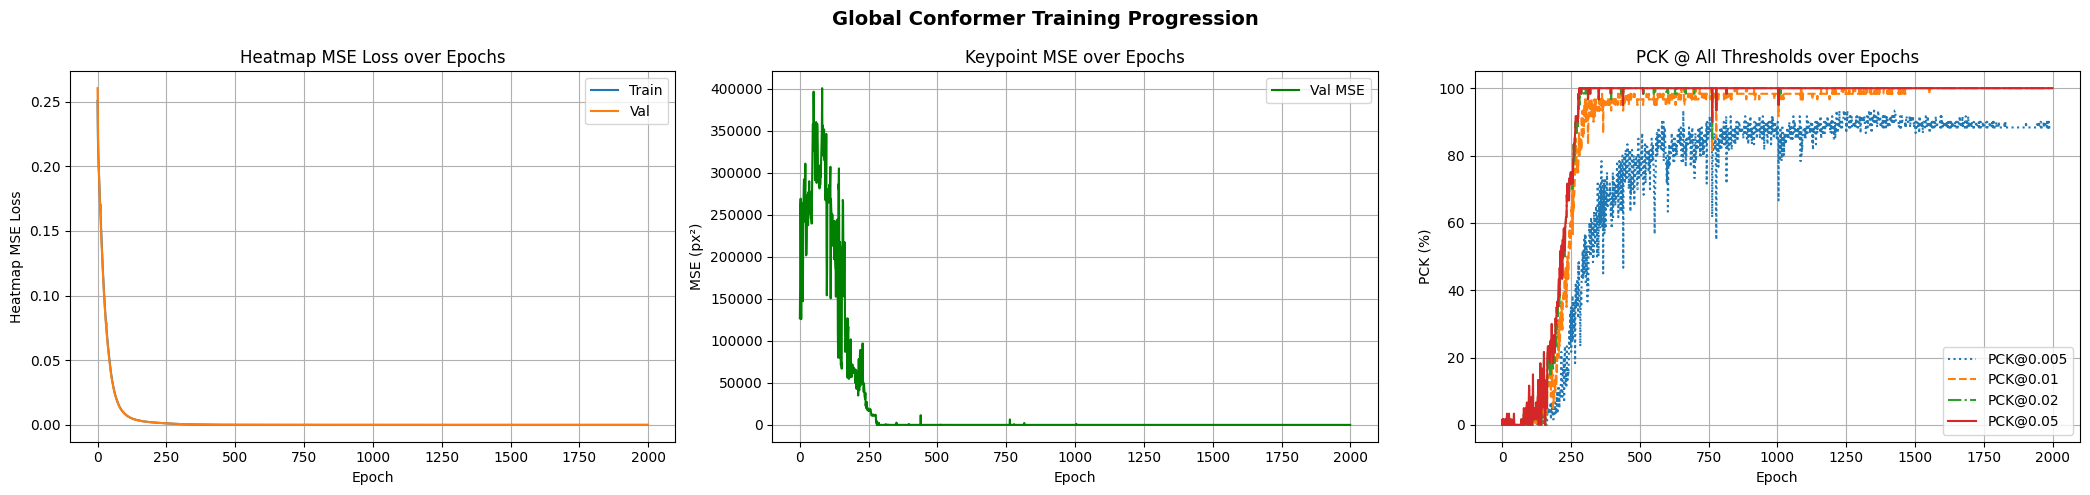

In [13]:
if 'train_losses' in locals():
    pck_005 = [v[0.005]*100 for v in val_pcks_all]
    pck_01  = [v[0.01] *100 for v in val_pcks_all]
    pck_02  = [v[0.02] *100 for v in val_pcks_all]
    pck_05  = [v[0.05] *100 for v in val_pcks_all]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    axes[0].plot(train_losses, label="Train"); axes[0].plot(val_losses, label="Val")
    axes[0].set_title("Heatmap MSE Loss over Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Heatmap MSE Loss")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(val_mses, color="green", label="Val MSE")
    axes[1].set_title("Keypoint MSE over Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE (px\u00b2)")
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(pck_005, linestyle=":",  label="PCK@0.005")
    axes[2].plot(pck_01,  linestyle="--", label="PCK@0.01")
    axes[2].plot(pck_02,  linestyle="-.", label="PCK@0.02")
    axes[2].plot(pck_05,  linestyle="-",  label="PCK@0.05")
    axes[2].set_title("PCK @ All Thresholds over Epochs")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("PCK (%)")
    axes[2].legend(); axes[2].grid(True)

    plt.suptitle("Global Conformer Training Progression", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("Training results not found — plotting skipped.")

## Test-Set Correction Angle Evaluation

The final trained model evaluates the held-out 10 % test set.  For each image
hemisphere the full Miniaci geometry pipeline runs: Fujisawa point, target ankle
intersection, and correction angle Alpha.  Results are reported as angular error
statistics and visualised with GT / prediction overlay diagrams.

In [14]:
if 'test_loader' in locals():
    model_global.eval()
    global_results = []

    with torch.no_grad():
        for batch in test_loader:
            imgs         = batch["image"].to(device)
            pred_hms     = torch.sigmoid(model_global(imgs))
            coords_batch = extract_coordinates(pred_hms.cpu(), scale_factor=1.0/HEATMAP_SCALE).numpy()
            gts_batch    = batch["keypoint"].numpy()
            paths_batch  = batch["img_path"]
            orig_sizes   = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c, gt_c, path_b = coords_batch[b], gts_batch[b], paths_batch[b]

                res_l = res_r = None
                for base, hemi_key in [(0, "res_l"), (6, "res_r")]:
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if all(k in pts_gt for k in _SIDE_KEYS) and all(k in pts_pred for k in _SIDE_KEYS):
                        gt_alpha,   gt_fuji,  gt_ank,  gt_targ  = evaluate_side_geometry(pts_gt)
                        pred_alpha, p_fuji,   p_ank,   p_targ   = evaluate_side_geometry(pts_pred)
                        pts_gt.update(fujisawa=gt_fuji,  ankle_c=gt_ank,  target_at_ankle=gt_targ)
                        pts_pred.update(fujisawa=p_fuji, ankle_c=p_ank,   target_at_ankle=p_targ)
                        result = {"side": ("Left" if base==0 else "Right") + " Image Hemisphere",
                                  "gt_angle": gt_alpha, "pred_angle": pred_alpha,
                                  "gt_pts": pts_gt,     "pred_pts": pts_pred}
                        if hemi_key == "res_l": res_l = result
                        else:                   res_r = result

                if res_l or res_r:
                    global_results.append({"img_path": path_b,
                                           "filename": os.path.basename(path_b),
                                           "res_l": res_l, "res_r": res_r})

    print(f"Inference complete: {len(global_results)} radiographs processed.")
else:
    print("Test loader not initialised — inference skipped.")

Inference complete: 6 radiographs processed.



TEST-SET PERFORMANCE SUMMARY
Evaluated hemisphere cases: 11 (5 left, 6 right)
Mean absolute error (all):        0.4651°
Mean absolute error (left hemi):  0.4796°
Mean absolute error (right hemi): 0.4529°
Std dev of abs errors (all):      0.2694°
Max absolute error    (all):      0.9910°


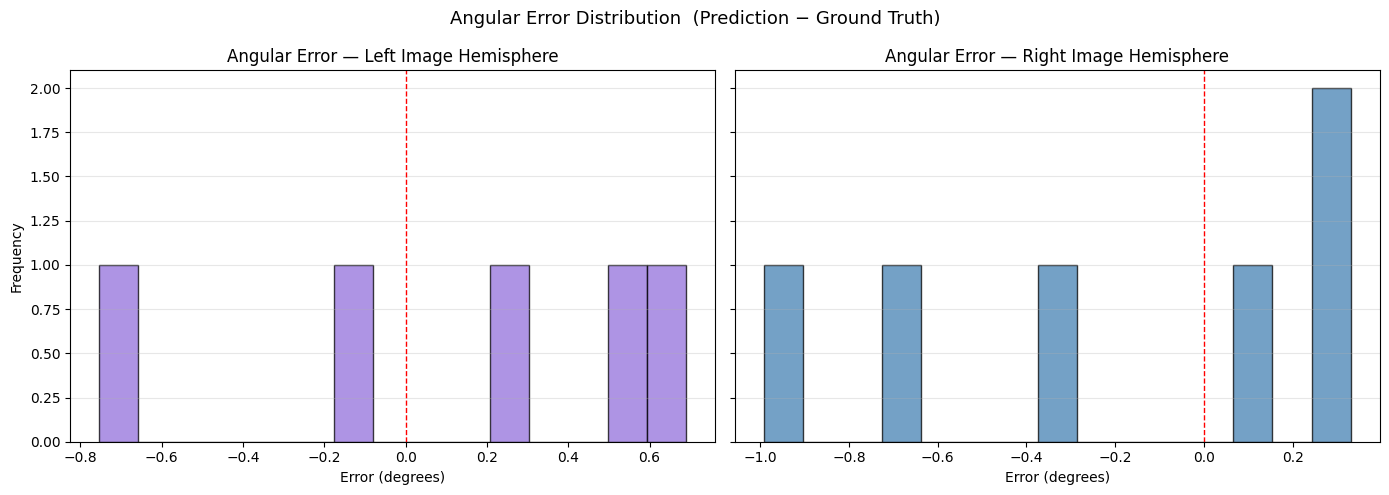

In [15]:
if 'global_results' in locals() and global_results:
    all_errors_lh, all_errors_rh = [], []
    for item in global_results:
        if item["res_l"]: all_errors_lh.append(item["res_l"]["pred_angle"] - item["res_l"]["gt_angle"])
        if item["res_r"]: all_errors_rh.append(item["res_r"]["pred_angle"] - item["res_r"]["gt_angle"])
    all_errors = all_errors_lh + all_errors_rh

    if all_errors:
        abs_all = [abs(e) for e in all_errors]

        print("\n" + "="*55)
        print("TEST-SET PERFORMANCE SUMMARY")
        print("="*55)
        print(f"Evaluated hemisphere cases: {len(all_errors)} "
              f"({len(all_errors_lh)} left, {len(all_errors_rh)} right)")
        print(f"Mean absolute error (all):        {np.mean(abs_all):.4f}\u00b0")
        if all_errors_lh:
            print(f"Mean absolute error (left hemi):  {np.mean([abs(e) for e in all_errors_lh]):.4f}\u00b0")
        if all_errors_rh:
            print(f"Mean absolute error (right hemi): {np.mean([abs(e) for e in all_errors_rh]):.4f}\u00b0")
        print(f"Std dev of abs errors (all):      {np.std(abs_all):.4f}\u00b0")
        print(f"Max absolute error    (all):      {np.max(abs_all):.4f}\u00b0")
        print("="*55)

        fig, (ax_lh, ax_rh) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        for ax, errors, label, color in [
            (ax_lh, all_errors_lh, "Left Image Hemisphere",  "mediumpurple"),
            (ax_rh, all_errors_rh, "Right Image Hemisphere", "steelblue"),
        ]:
            if errors:
                ax.hist(errors, bins=15, color=color, edgecolor="black", alpha=0.75)
                ax.axvline(0, color="red", linestyle="dashed", linewidth=1)
                ax.set_title(f"Angular Error — {label}")
                ax.set_xlabel("Error (degrees)"); ax.grid(True, axis="y", alpha=0.3)
            else:
                ax.set_visible(False)
        ax_lh.set_ylabel("Frequency")
        fig.suptitle("Angular Error Distribution  (Prediction − Ground Truth)", fontsize=13)
        plt.tight_layout(); plt.show()
else:
    print("No inference results found — evaluation skipped.")

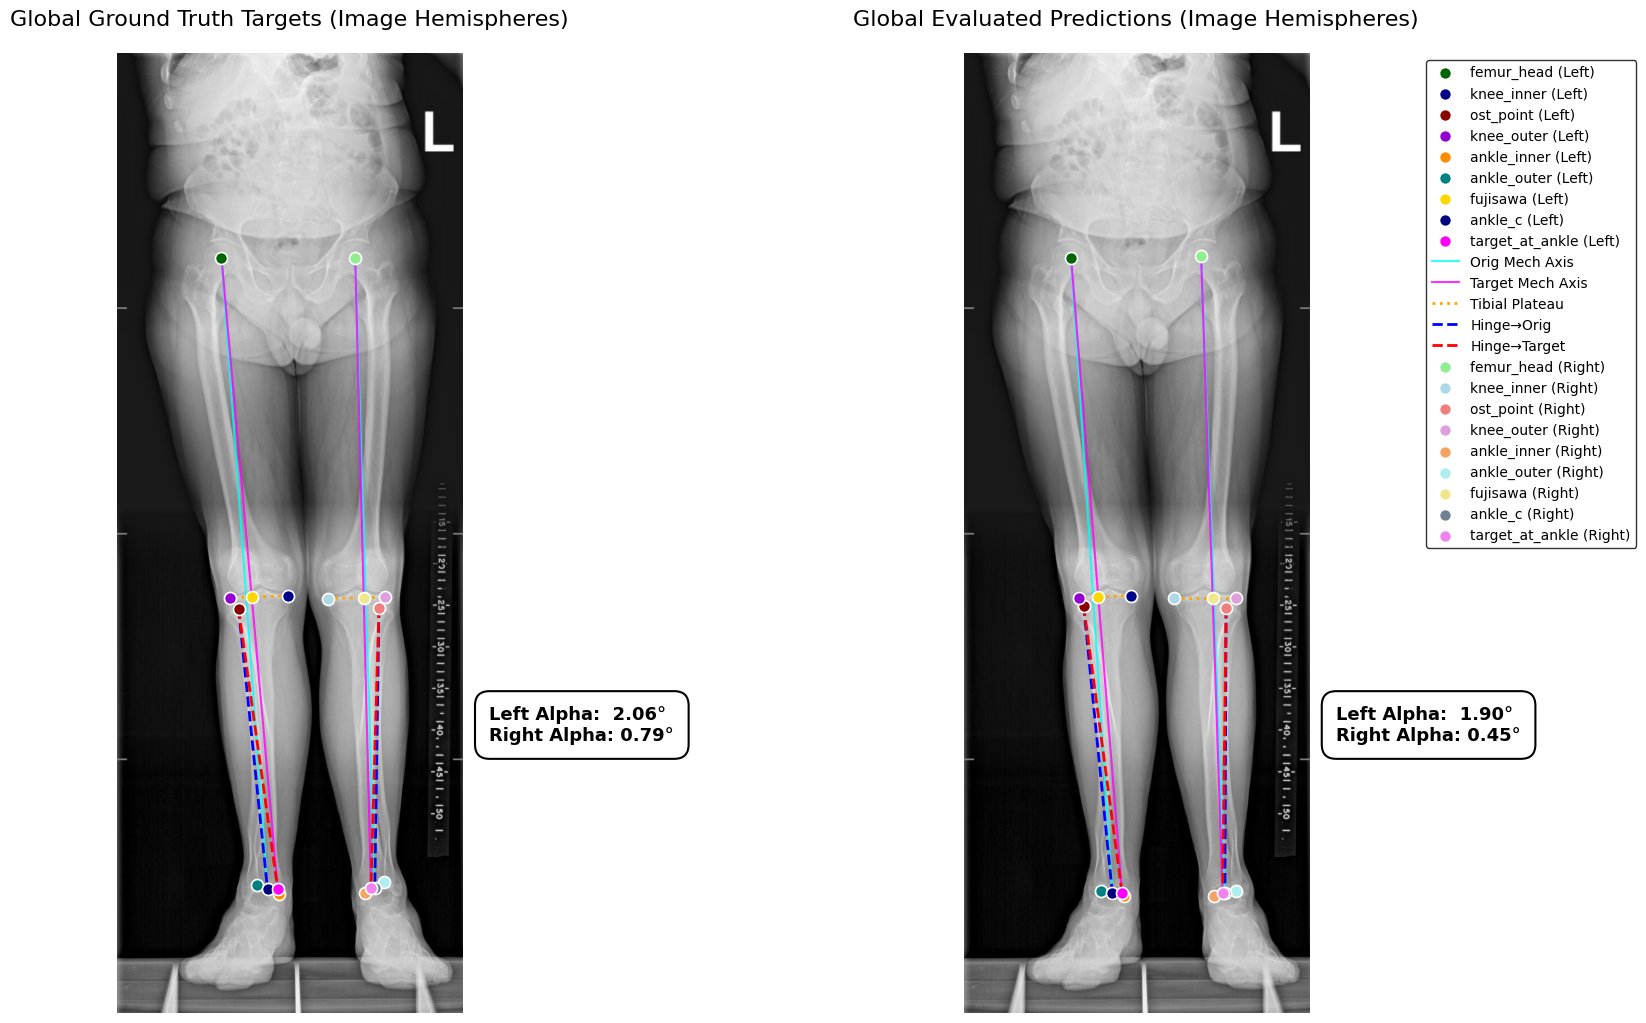

Overlay rendered for: 59_0.png


In [16]:
if 'global_results' in locals() and global_results:
    candidates   = [s for s in global_results if s["res_l"] and s["res_r"]]
    sample_entry = random.choice(candidates) if candidates else random.choice(global_results)
    img_target   = Image.open(sample_entry["img_path"]).convert("RGB")

    fig, (ax_gt, ax_pred) = plt.subplots(1, 2, figsize=(22, 12))

    def draw_overlay(ax, data_item, is_gt=True):
        key   = "gt_angle" if is_gt else "pred_angle"
        title = ("Global Ground Truth Targets" if is_gt else "Global Evaluated Predictions")
        ax.imshow(img_target, cmap="gray")
        ax.set_title(title + " (Image Hemispheres)", fontsize=16, pad=20)

        lines = []
        if data_item.get("res_l"): lines.append(f"Left Alpha:  {data_item['res_l'][key]:.2f}\u00b0")
        if data_item.get("res_r"): lines.append(f"Right Alpha: {data_item['res_r'][key]:.2f}\u00b0")
        if lines:
            ax.text(1.08, 0.3, "\n".join(lines), transform=ax.transAxes,
                    ha="left", va="center", fontsize=13, weight="bold", color="black",
                    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.8", linewidth=1.5))

        for s_tag in ["res_l", "res_r"]:
            sd = data_item[s_tag]
            if not sd: continue
            pts    = sd["gt_pts"] if is_gt else sd["pred_pts"]
            suffix = "_lh" if s_tag == "res_l" else "_rh"
            side   = "Left" if s_tag == "res_l" else "Right"

            for k_name, coord in pts.items():
                if isinstance(coord, np.ndarray) and coord.shape == (2,):
                    ax.scatter(coord[0], coord[1], s=75,
                               color=LANDMARK_COLORS.get(f"{k_name}{suffix}", "magenta"),
                               edgecolors="white", linewidths=1.2, zorder=5,
                               label=f"{k_name} ({side})")

            ax.plot([pts["femur_head"][0], pts["ankle_c"][0]],
                    [pts["femur_head"][1], pts["ankle_c"][1]],
                    color="cyan",    linestyle="-",  linewidth=1.5, alpha=0.8, zorder=2, label="Orig Mech Axis")
            ax.plot([pts["femur_head"][0], pts["target_at_ankle"][0]],
                    [pts["femur_head"][1], pts["target_at_ankle"][1]],
                    color="magenta", linestyle="-",  linewidth=1.5, alpha=0.8, zorder=3, label="Target Mech Axis")
            ax.plot([pts["knee_inner"][0], pts["knee_outer"][0]],
                    [pts["knee_inner"][1], pts["knee_outer"][1]],
                    color="orange",  linestyle=":",  linewidth=2,              zorder=4, label="Tibial Plateau")
            ax.plot([pts["ost_point"][0], pts["ankle_c"][0]],
                    [pts["ost_point"][1], pts["ankle_c"][1]],
                    color="blue",    linestyle="--", linewidth=2,              zorder=4, label="Hinge→Orig")
            ax.plot([pts["ost_point"][0], pts["target_at_ankle"][0]],
                    [pts["ost_point"][1], pts["target_at_ankle"][1]],
                    color="red",     linestyle="--", linewidth=2,              zorder=4, label="Hinge→Target")

        ax.axis("off")
        if not is_gt:
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            if by_label:
                ax.legend(by_label.values(), by_label.keys(),
                          bbox_to_anchor=(1.32, 1.0), loc="upper left",
                          fontsize=10, frameon=True, facecolor="white", edgecolor="black")

    draw_overlay(ax_gt,   sample_entry, is_gt=True)
    draw_overlay(ax_pred, sample_entry, is_gt=False)
    plt.subplots_adjust(left=0.05, bottom=0.1, top=0.9, wspace=0.35, right=0.72)
    plt.show()
    print(f"Overlay rendered for: {sample_entry['filename']}")
else:
    print("No inference results found — visualisation skipped.")